## 01 - Prédiction de l'humidité du sol à J+1

Dans ce notebook, nous allons construire un modèle de régression pour prédire l'humidité du sol au jour suivant.

La variable cible est `Soil_Moisture_J1`.

Le modèle utilisé est `RandomForestRegressor`.

L'évaluation sera faite avec :

- MAE
- RMSE
- R²



In [3]:

import pandas as pd
import numpy as np


In [5]:
df = pd.read_csv(r"C:\Users\kerro\OneDrive\Bureau\smart-agri\data\processed\irrigation_prediction_cols19.csv")

df.head(15)

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need,Stress_Index,Soil_Moisture_J1
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Yes,1.98,South,Low,38.53,42.73500
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Yes,33.56,Central,Medium,47.40,43.26370
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Yes,34.62,South,Low,42.22,50.22325
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Yes,84.03,North,Medium,56.29,10.49490
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,No,60.86,South,Medium,48.94,41.90145
5,Silt,5.10,20.50,0.37,1.43,33.34,62.51,402.92,7.03,13.55,Rice,Sowing,Zaid,Yes,7.33,East,Medium,55.60,6.63830
6,Sandy,7.44,22.70,0.59,2.95,28.02,58.50,764.95,7.08,7.38,Rice,Flowering,Kharif,No,51.47,West,Medium,63.31,26.16425
7,Sandy,7.68,40.23,0.62,3.30,35.60,79.10,833.33,5.17,3.73,Wheat,Vegetative,Zaid,Yes,118.96,West,Low,39.11,61.80895
8,Clay,5.42,36.73,0.74,1.52,16.59,76.88,2476.03,10.34,1.80,Maize,Flowering,Kharif,Yes,107.25,Central,Low,25.55,85.74245
9,Loamy,6.26,19.58,0.36,1.67,31.14,74.30,1474.55,8.53,17.68,Rice,Vegetative,Rabi,Yes,97.92,Central,Medium,49.93,39.32525


## 02. Séparation entre X et y

Dans cette partie, nous séparons les variables explicatives et la variable cible.

- `X` : les variables utilisées pour prédire
- `y` : la variable cible `Soil_Moisture_J1`

Nous supprimons `Irrigation_Need` car elle correspond à la cible de classification, alors que ce notebook traite un problème de régression.

In [6]:
X = df.drop(["Soil_Moisture_J1", "Irrigation_Need"], axis=1)
y = df["Soil_Moisture_J1"]

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

Shape de X : (10000, 17)
Shape de y : (10000,)


## 03. Identification des colonnes numériques et catégorielles

Avant le prétraitement, nous devons identifier deux types de colonnes :

- les colonnes numériques,
- les colonnes catégorielles.


In [9]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "string"]).columns

print("Colonnes numériques :")
print(numeric_cols)

print("\nNombre de colonnes numériques :", len(numeric_cols))

print("\nColonnes catégorielles :")
print(categorical_cols)

print("\nNombre de colonnes catégorielles :", len(categorical_cols))

Colonnes numériques :
Index(['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
       'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
       'Wind_Speed_kmh', 'Previous_Irrigation_mm', 'Stress_Index'],
      dtype='str')

Nombre de colonnes numériques : 11

Colonnes catégorielles :
Index(['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
       'Mulching_Used', 'Region'],
      dtype='str')

Nombre de colonnes catégorielles : 6


## 04. Split train/test

Nous divisons la dataset en :

- 80% pour l'entraînement,
- 20% pour le test.

Dans un problème de régression, nous n'utilisons pas `stratify`, car la cible est une valeur numérique et non une classe.

In [10]:
from sklearn.model_selection import train_test_split    


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("Shape de X_train :", X_train.shape)
print("Shape de X_test :", X_test.shape)
print("Shape de y_train :", y_train.shape)
print("Shape de y_test :", y_test.shape)

Shape de X_train : (8000, 17)
Shape de X_test : (2000, 17)
Shape de y_train : (8000,)
Shape de y_test : (2000,)


## 05.Standardisation des variables numériques

Dans cette étape, nous allons standardiser les colonnes numériques de la dataset.

La standardisation permet de transformer les variables numériques afin qu'elles aient une moyenne proche de 0 et un écart-type proche de 1.





In [13]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled = scaler.fit_transform(X_test[numeric_cols])

## 06.Encodage des variables catégorielles

Dans cette étape, nous allons encoder les colonnes catégorielles.

elles contiennent des valeurs textuelles.

Cette méthode transforme chaque catégorie en une nouvelle colonne numérique contenant 0 ou 1.


In [16]:
from  sklearn.preprocessing import OneHotEncoder

In [19]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

## 07.Fusion des données prétraitées

Après la standardisation des variables numériques et l'encodage des variables catégorielles, nous devons regrouper les deux parties dans une seule matrice finale.

Nous combinons donc :

- les colonnes numériques standardisées,
- les colonnes catégorielles encodées.

Cette matrice finale sera utilisée pour entraîner le modèle `RandomForestRegressor`.

In [21]:
X_train_prepared = np.hstack([X_train_scaled, X_train_encoded])
X_test_prepared = np.hstack([X_test_scaled, X_test_encoded])

print("Shape X_train_prepared :", X_train_prepared.shape)
print("Shape X_test_prepared :", X_test_prepared.shape)

Shape X_train_prepared : (8000, 35)
Shape X_test_prepared : (2000, 35)


## 08. Création du modèle RandomForestRegressor

Nous créons maintenant le modèle de régression.

Le modèle utilisé est `RandomForestRegressor`.

Il est composé de plusieurs arbres de décision. Chaque arbre donne une prédiction, puis le modèle calcule une moyenne pour obtenir la prédiction finale.



In [23]:
from sklearn.ensemble import RandomForestRegressor 

In [33]:
model = RandomForestRegressor(n_estimators=200, random_state=42) 

## 09. Entraînement du modèle

Nous entraînons le modèle avec les données préparées.

Nous utilisons :

- `X_train_prepared` : les variables explicatives après standardisation et encodage.
- `y_train` : la variable cible à prédire.

Le modèle va apprendre la relation entre les variables d'entrée et l'humidité du sol au jour suivant.

In [34]:
model.fit(X_train_prepared, y_train) 


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## 10. Prédiction sur les données de test

Après l'entraînement, nous utilisons le modèle pour prédire l'humidité du sol sur les données de test.



In [39]:
y_pred = model.predict(X_test_prepared)


## 11. Évaluation du modèle

Nous évaluons le modèle avec :

- `MAE`,
- `RMSE`,
- `R²`.

La métrique principale est `MAE`.

Si le MAE est égal à 2.5, cela signifie que le modèle se trompe en moyenne de 2.5 unités d'humidité du sol.

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [38]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

MAE : 2.2351158757499987
RMSE : 2.8093168432035105
R² : 0.9835359395090105


## 12.Interprétation des résultats

Après l'entraînement du modèle `RandomForestRegressor`, nous avons obtenu les résultats suivants :

- **MAE = 2.24**
- **RMSE = 2.81**
- **R² = 0.98**

Le **MAE** indique que le modèle se trompe en moyenne d'environ **2.24 unités d'humidité du sol**.  
 -> Cela signifie que les prédictions du modèle sont proches des valeurs réelles.

Le **RMSE** est égal à **2.81**. Cette valeur est légèrement supérieure au MAE.
 -> ce qui montre que le modèle ne fait pas beaucoup de grandes erreurs.

Le **R² = 0.98** indique que le modèle explique environ **98% de la variation** de la variable cible `Soil_Moisture_J1`.  
  -> Cela signifie que le modèle arrive à très bien apprendre la relation entre les variables d'entrée et l'humidité du sol estimée au jour suivant.





## 13. Comparaison entre les valeurs réelles et les valeurs prédites

Nous créons un tableau pour comparer :

- la vraie valeur de `Soil_Moisture_J1`,
- la valeur prédite par le modèle.

In [40]:
resultat = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})
resultat 

,y_test,y_pred
6252,4.69855,6.417786
4684,30.65295,31.338267
1731,12.67280,18.386833
4742,61.12915,55.905452
4521,46.04235,45.133205
...,...,...
6412,78.35750,76.451655
8285,59.70465,58.052669
7853,50.10510,45.350262
1095,80.37630,78.734219


### Visualisation des prédictions

In [43]:
import matplotlib.pyplot as plt

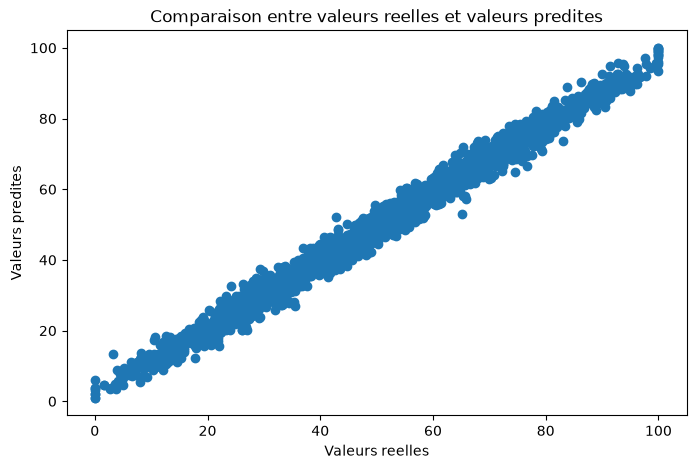

In [44]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Valeurs reelles")
plt.ylabel("Valeurs predites")
plt.title("Comparaison entre valeurs reelles et valeurs predites")
plt.show()

## 14. Sauvegarde du modèle

Nous sauvegardons le pipeline complet, c'est-à-dire :

- le preprocessing,
- le modèle RandomForestRegressor.

Le fichier sauvegardé s'appelle `rf_model.pkl`.

In [45]:
import os
import joblib

In [46]:
os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/rf_model.pkl")

print("Modèle sauvegardé avec succès.")

Modèle sauvegardé avec succès.


## Conclusion

Dans ce notebook, nous avons développé un modèle de régression pour prédire l'humidité du sol estimée au jour suivant, représentée par la variable `Soil_Moisture_J1`.

Nous avons commencé par séparer les variables explicatives `X` et la variable cible `y`. Les colonnes numériques ont été standardisées avec `StandardScaler`, tandis que les colonnes catégorielles ont été encodées avec `OneHotEncoder`. Ces étapes ont permis de préparer les données avant l'entraînement du modèle.

Nous avons ensuite divisé les données en deux parties : 80% pour l'entraînement et 20% pour le test. Le modèle utilisé est `RandomForestRegressor`, qui est adapté aux données tabulaires et aux problèmes de régression.

Les résultats obtenus sont les suivants :

- `MAE = 2.24`
- `RMSE = 2.81`
- `R² = 0.98`


Globalement, le modèle donne de très bonnes performances pour la prédiction de `Soil_Moisture_J1`.

Cependant, il est important de préciser que `Soil_Moisture_J1` est une variable estimée, car la dataset utilisée ne contient pas de vraie dimension temporelle comme une colonne `Date` ou `Day`. Les résultats doivent donc être considérés comme une première simulation de prédiction de l'humidité du sol au jour suivant.

